In [2]:
import openai
from dotenv import load_dotenv

load_dotenv()

%load_ext mypy_ipython

The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


### Import relevant classes


In [3]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal

### Define the State


In [4]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

### Define the Nodes


In [8]:
chat = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    seed=42,
    max_completion_tokens=100,
)

In [9]:
def ask_question(state: State) -> State:
    print(f"\n----> Entered ask_question:")

    print("What is your question?")

    return State(messages=[HumanMessage(content=input())])

In [7]:
def chatbot(state: State) -> State:
    print(f"\n----> Entering chatbot:")

    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages=[response])

In [11]:
def ask_another_question(state: State) -> State:
    print(f"\n----> Entered ask_another_question:")

    print("What is your next question? (yes/no)")

    return State(messages=[HumanMessage(content=input())])

### Define the Routing Function


In [49]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:
    if state["messages"][0].content.lower() in ["yes", "y"]:
        return "ask_question"
    else:
        return "__end__"

### Define the Graph


In [50]:
graph = StateGraph(State)

In [51]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
    path_map={"ask_question": "ask_question", "__end__": END},
)

In [52]:
graph_compiled = graph.compile()

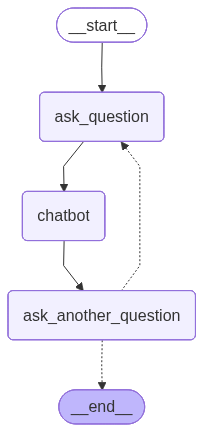

In [53]:
graph_compiled

In [54]:
graph_compiled.invoke(State(messages=[]))


----> Entered ask_question:
What is your question?

----> Entering chatbot:
================================== Ai Message ==================================

Certainly! Here's a poem about nature:

---

Beneath the sky’s embracing blue,  
Where whispers dance on morning dew,  
The trees in silent grandeur stand,  
Guardians of the ancient land.

The rivers sing a silver song,  
Through valleys deep and mountains strong,  
Their waters weave a timeless thread,  
Where life and dreams are gently fed.

The blossoms bloom with colors bright,  
A canvas kissed by soft sunlight,  
Each petal tells a tale anew,  
Of

----> Entered ask_another_question:
What is your next question? (yes/no)

----> Entered ask_question:
What is your question?

----> Entering chatbot:
================================== Ai Message ==================================

I don't have a physical form, so I don't wear wigs or any clothing. But I can help answer questions about wigs or offer advice if you're interested!


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}